# Compare Model Trajectories

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma

from confrdm.utils import scaled_gamma_density_derivative


In [37]:
rng = np.random.default_rng(2025)

In [38]:
color_dict = {
    0: "darkgreen",
    1: "indianred"
}

In [39]:
dt = 0.001
T = 1
time = np.arange(dt, T, dt)

def get_gamma_drift(t, A, alpha, tau):
    return A * gamma.pdf(t, a=alpha, scale=tau)


In [40]:
def simulate_rdm_trajectory(v_true, v_false, sigma_true, sigma_false=1.0, n_sims=10):
    # Expected trajectories (noiseless)
    exp_true = np.cumsum(np.full_like(time, v_true) * dt)
    exp_false = np.cumsum(np.full_like(time, v_false) * dt)

    # Simulations
    sim_true = np.zeros((n_sims, len(time)))
    sim_false = np.zeros((n_sims, len(time)))
    
    for i in range(n_sims):
        noise_t = np.random.normal(0, sigma_true * np.sqrt(dt), len(time))
        noise_d = np.random.normal(0, sigma_false * np.sqrt(dt), len(time))
        sim_true[i] = exp_true + np.cumsum(noise_t)
        sim_false[i] = exp_false + np.cumsum(noise_d)
        
    return exp_true, exp_false, sim_true, sim_false

In [49]:
def simulate_rdmc_trajectory(v_true, v_false, sigma_true, A, alpha, tau, sigma_false=1.0, n_sims=10):
    gamma_curve = scaled_gamma_density_derivative(time, np.abs(A), tau, alpha)

    if A > 0.0:
        exp_true = np.cumsum((np.full_like(time, v_true) + gamma_curve) * dt) 
        exp_false = np.cumsum(np.full_like(time, v_false) * dt)
    else:
        exp_true = np.cumsum(np.full_like(time, v_true) * dt) 
        exp_false = np.cumsum((np.full_like(time, v_false) + gamma_curve) * dt)
    
    # Simulations
    sim_true = np.zeros((n_sims, len(time)))
    sim_false = np.zeros((n_sims, len(time)))
    
    for i in range(n_sims):
        noise_t = np.random.normal(0, sigma_true * np.sqrt(dt), len(time))
        noise_d = np.random.normal(0, sigma_false * np.sqrt(dt), len(time))
        sim_true[i] = exp_true + np.cumsum(noise_t)
        sim_false[i] = exp_false + np.cumsum(noise_d)
        
        
    return exp_true, exp_false, sim_true, sim_false


In [50]:
def simulate_dmc_trajectory(v_diff, A, alpha, tau, sigma=1.0, n_sims=10):
    gamma_pulse = scaled_gamma_density_derivative(time, A, tau, alpha)
    
    # Congruent: Target + Pulse
    drift_cong = v_diff + gamma_pulse
    exp_cong = np.cumsum(drift_cong * dt)
    
    # Incongruent: Target - Pulse
    drift_inc = v_diff - gamma_pulse
    exp_inc = np.cumsum(drift_inc * dt)
    
    sim_cong = np.zeros((n_sims, len(time)))
    sim_inc = np.zeros((n_sims, len(time)))
    
    for i in range(n_sims):
        sim_cong[i] = exp_cong + np.cumsum(np.random.normal(0, sigma * np.sqrt(dt), len(time)))
        sim_inc[i] = exp_inc + np.cumsum(np.random.normal(0, sigma * np.sqrt(dt), len(time)))
        
    return exp_cong, exp_inc, sim_cong, sim_inc


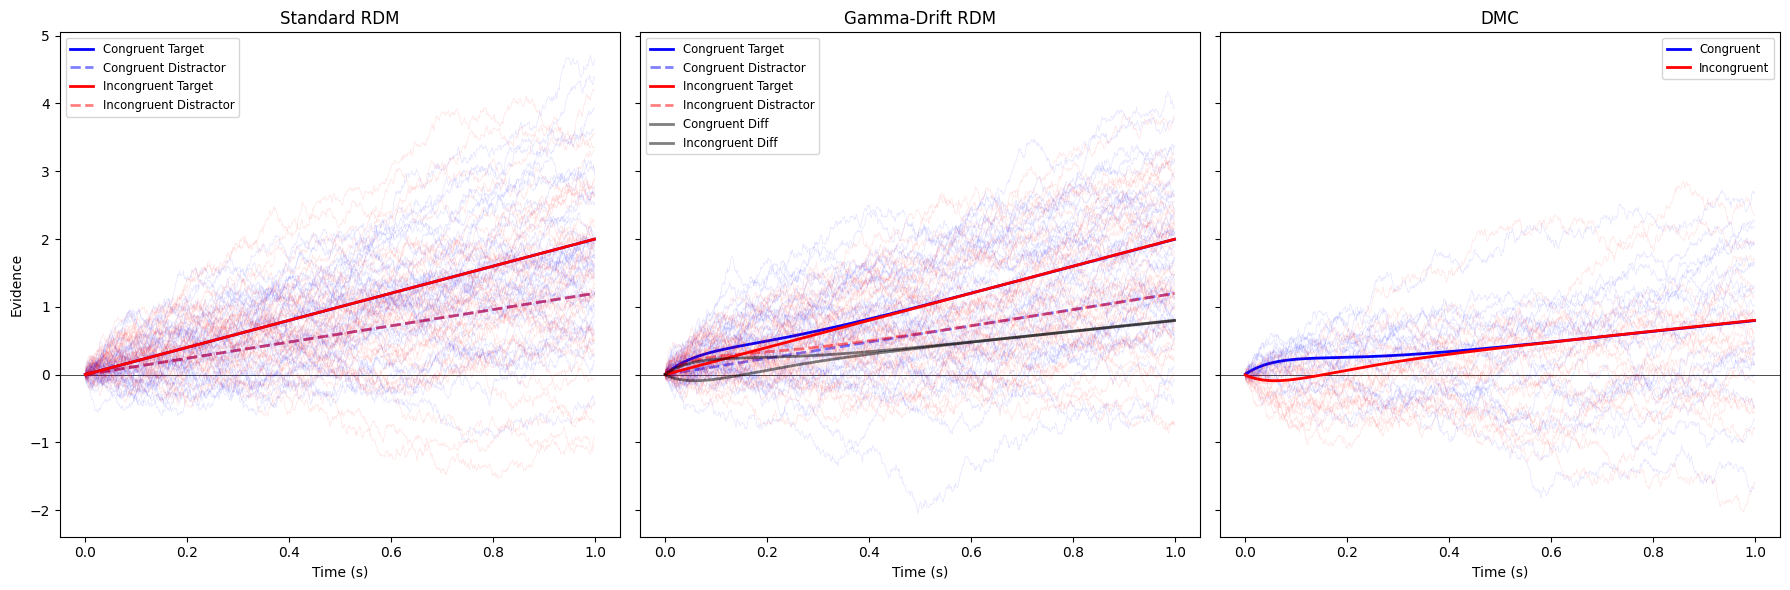

In [53]:
n_sims = 20

# Standard RDM params
v_rdm_cong_true = 2.0
v_rdm_cong_false = 1.2
v_rdm_inc_true = 2.0
v_rdm_inc_false = 1.2

sigma_true = 1.0

# 3. Run Simulations
# Standard RDM
# Congruent
exp_rdm_cong_true, exp_rdm_cong_false, sim_rdm_cong_true, sim_rdm_cong_false = simulate_rdm_trajectory(
    v_rdm_cong_true, v_rdm_cong_false, sigma_true, n_sims=n_sims
)
# Incongruent
exp_rdm_inc_true, exp_rdm_inc_false, sim_rdm_inc_true, sim_rdm_inc_false = simulate_rdm_trajectory(
    v_rdm_inc_true, v_rdm_inc_false, sigma_true, n_sims=n_sims
)

# 2. Parameters
# Gamma parameters
A = 0.15
alpha = 2.0
tau = 0.09

# Gamma RDM
exp_rdmc_cong_true, exp_rdmc_cong_false, sim_rdmc_cong_true, sim_rdmc_cong_false = simulate_rdmc_trajectory(
    v_rdm_cong_true, v_rdm_cong_false, sigma_true, A, alpha, tau, n_sims=n_sims
)
# Incongruent
exp_rdmc_inc_true, exp_rdmc_inc_false, sim_rdmc_inc_true, sim_rdmc_inc_false = simulate_rdmc_trajectory(
    v_rdm_inc_true, v_rdm_inc_false, sigma_true, -A, alpha, tau, n_sims=n_sims
)

# DMC params
v_dmc = v_rdm_cong_true - v_rdm_cong_false

# DMC
exp_dmc_c, exp_dmc_i, sim_dmc_c, sim_dmc_i = simulate_dmc_trajectory(
    v_dmc, A, alpha, tau, sigma=sigma_true, n_sims=n_sims
)

# 4. Plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# Helper for plotting simulations
def plot_sims(ax, time, sims, color):
    for s in sims:
        ax.plot(time, s, color=color, alpha=0.1, linewidth=0.5)

# Plot 1: Standard RDM
ax = axes[0]
ax.set_title("Standard RDM")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Evidence")
ax.axhline(0, color='k', lw=0.5)
# Congruent
ax.plot(time, exp_rdm_cong_true, 'b-', lw=2, label='Congruent Target')
ax.plot(time, exp_rdm_cong_false, 'b--', lw=2, alpha=0.5, label='Congruent Distractor')
plot_sims(ax, time, sim_rdm_cong_true, 'b')
plot_sims(ax, time, sim_rdm_cong_false, 'b')
# Incongruent
ax.plot(time, exp_rdm_inc_true, 'r-', lw=2, label='Incongruent Target')
ax.plot(time, exp_rdm_inc_false, 'r--', lw=2, alpha=0.5, label='Incongruent Distractor')
plot_sims(ax, time, sim_rdm_inc_true, 'r')
plot_sims(ax, time, sim_rdm_inc_false, 'r')
ax.legend(fontsize='small')

# Plot 2: Gamma RDM
ax = axes[1]
ax.set_title("Gamma-Drift RDM")
ax.set_xlabel("Time (s)")
ax.axhline(0, color='k', lw=0.5)
# Congruent
ax.plot(time, exp_rdmc_cong_true, 'b-', lw=2, label='Congruent Target')
ax.plot(time, exp_rdmc_cong_false, 'b--', lw=2, alpha=0.5, label='Congruent Distractor')
plot_sims(ax, time, sim_rdmc_cong_true, 'b')
plot_sims(ax, time, sim_rdmc_cong_false, 'b')
# Incongruent
ax.plot(time, exp_rdmc_inc_true, 'r-', lw=2, label='Incongruent Target')
ax.plot(time, exp_rdmc_inc_false, 'r--', lw=2, alpha=0.5, label='Incongruent Distractor')
plot_sims(ax, time, sim_rdmc_inc_true, 'r')
plot_sims(ax, time, sim_rdmc_inc_false, 'r')
# Difference
ax.plot(time, exp_rdmc_cong_true - exp_rdmc_cong_false, 'black', lw=2, alpha=0.5, label='Congruent Diff')
ax.plot(time, exp_rdmc_inc_true - exp_rdmc_inc_false, 'black', lw=2, alpha=0.5, label='Incongruent Diff')
ax.legend(fontsize='small')

# Plot 3: DMC
ax = axes[2]
ax.set_title("DMC")
ax.set_xlabel("Time (s)")
ax.axhline(0, color='k', lw=0.5)
# Congruent
ax.plot(time, exp_dmc_c, 'b-', lw=2, label='Congruent')
plot_sims(ax, time, sim_dmc_c, 'b')
# Incongruent
ax.plot(time, exp_dmc_i, 'r-', lw=2, label='Incongruent')
plot_sims(ax, time, sim_dmc_i, 'r')
ax.legend(fontsize='small')

plt.tight_layout()
plt.savefig('model_trajectories.png', dpi=300)